In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import GaiaSample, Local, StrictG, StrictBPRP, LindegrenC1, LindegrenC2, Deoutlier

from plotters import (
    plot_aitoff_diff,
    plot_period_abs_mag,
    plot_period_abs_mag_c12_comparison,
    plot_inlier_prob_period_luminosity_comparison,
)

In [2]:
query = """
SELECT *
FROM gaiadr3.vari_rrlyrae AS vr
JOIN gaiadr3.gaia_source AS gs
    ON vr.source_id = gs.source_id
"""

rrlyrae_sample = GaiaSample(query)
rrlyrae_low_dust = Local(rrlyrae_sample)
strict = StrictBPRP(StrictG(rrlyrae_low_dust))
c1 = LindegrenC1(strict)
c12 = LindegrenC2(c1)

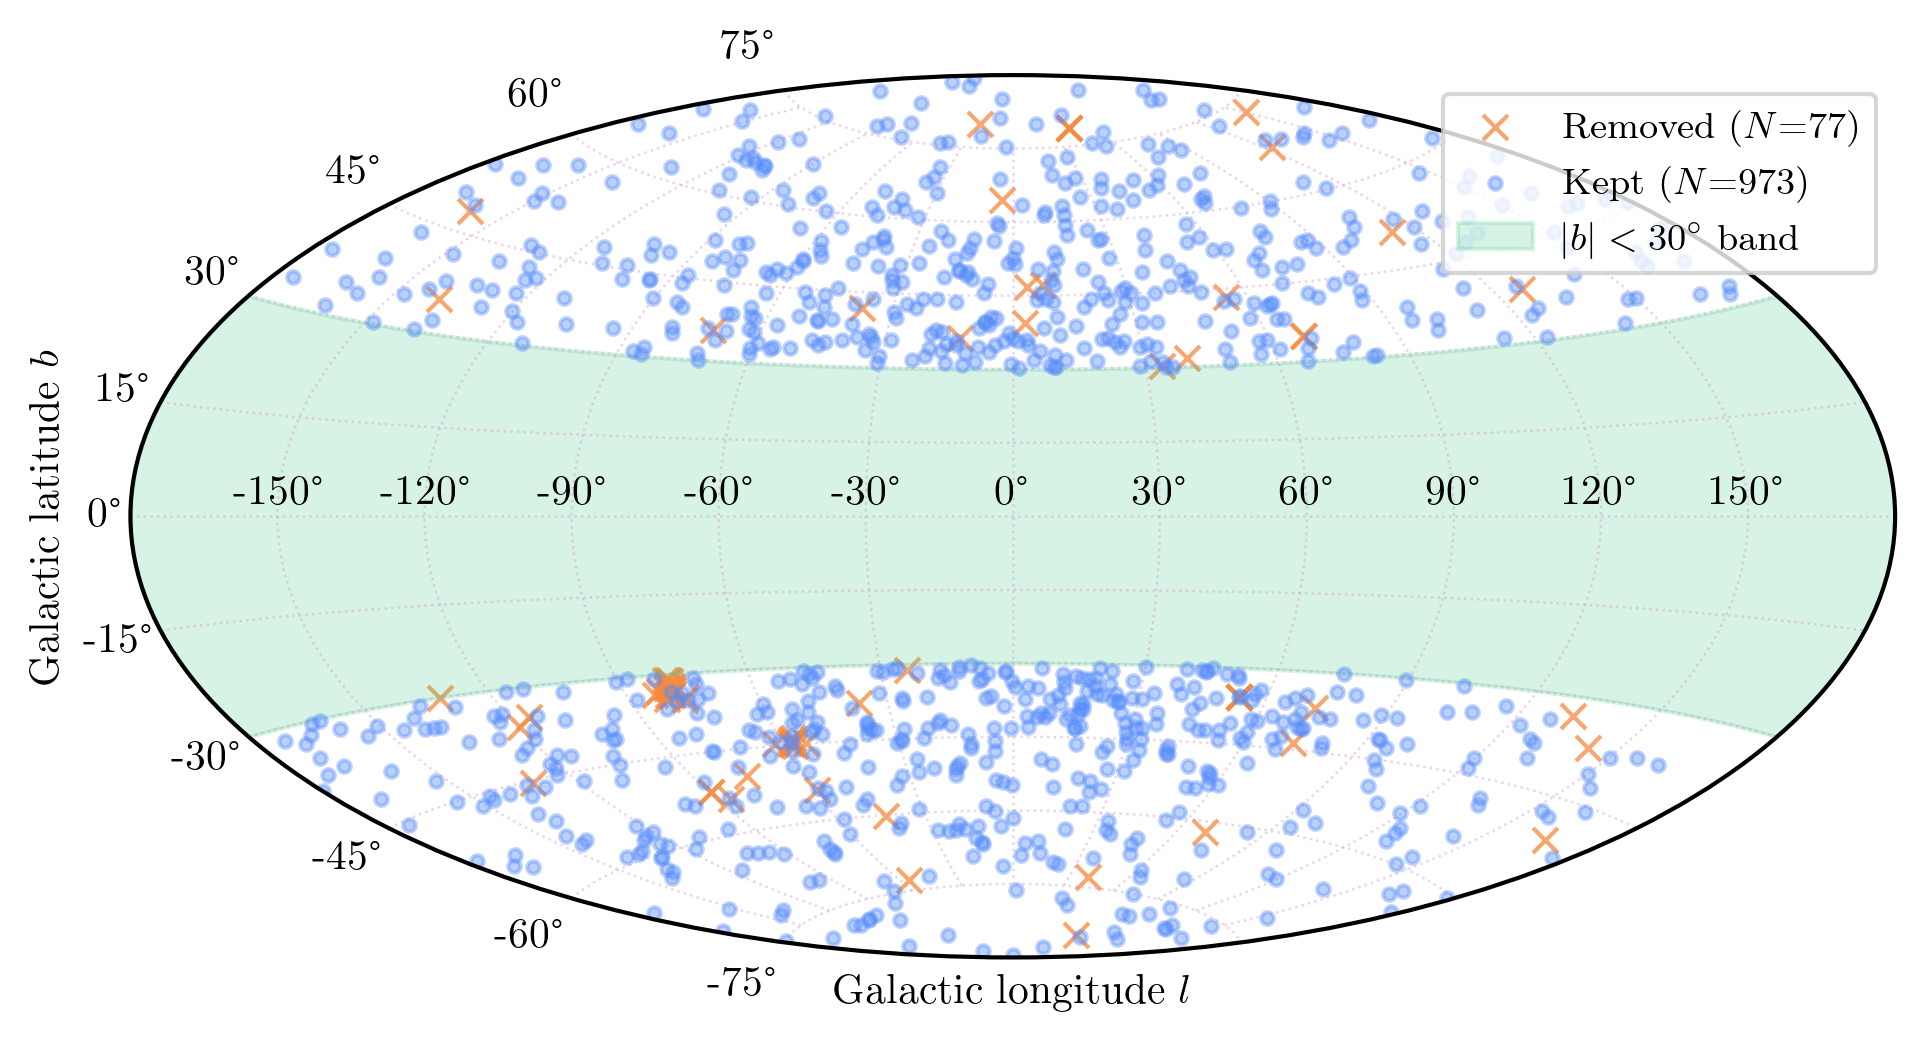

In [3]:
ax = plot_aitoff_diff(rrlyrae_low_dust, c12)
plt.show()

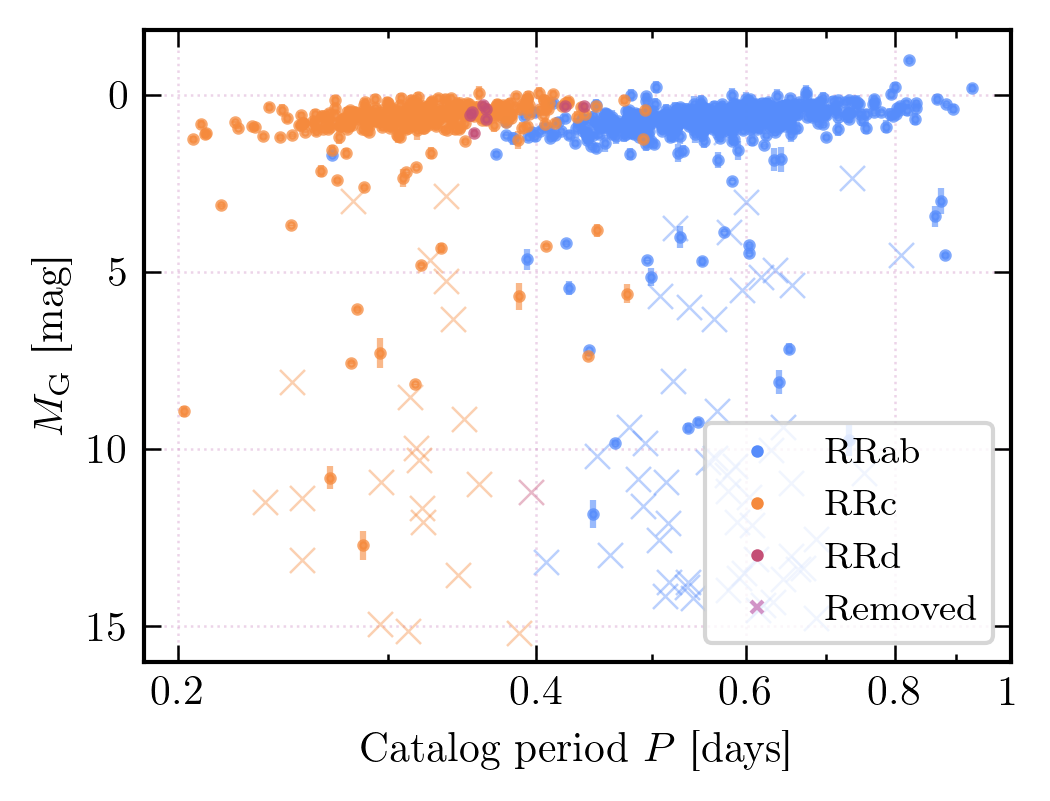

In [4]:
ax = plot_period_abs_mag_c12_comparison(rrlyrae_low_dust, c12)
plt.show()

In [5]:
clean = Deoutlier(c12)
rrlyrae_clean_data = clean.data

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig, logit_f]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 18 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig, logit_f]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig, logit_f]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


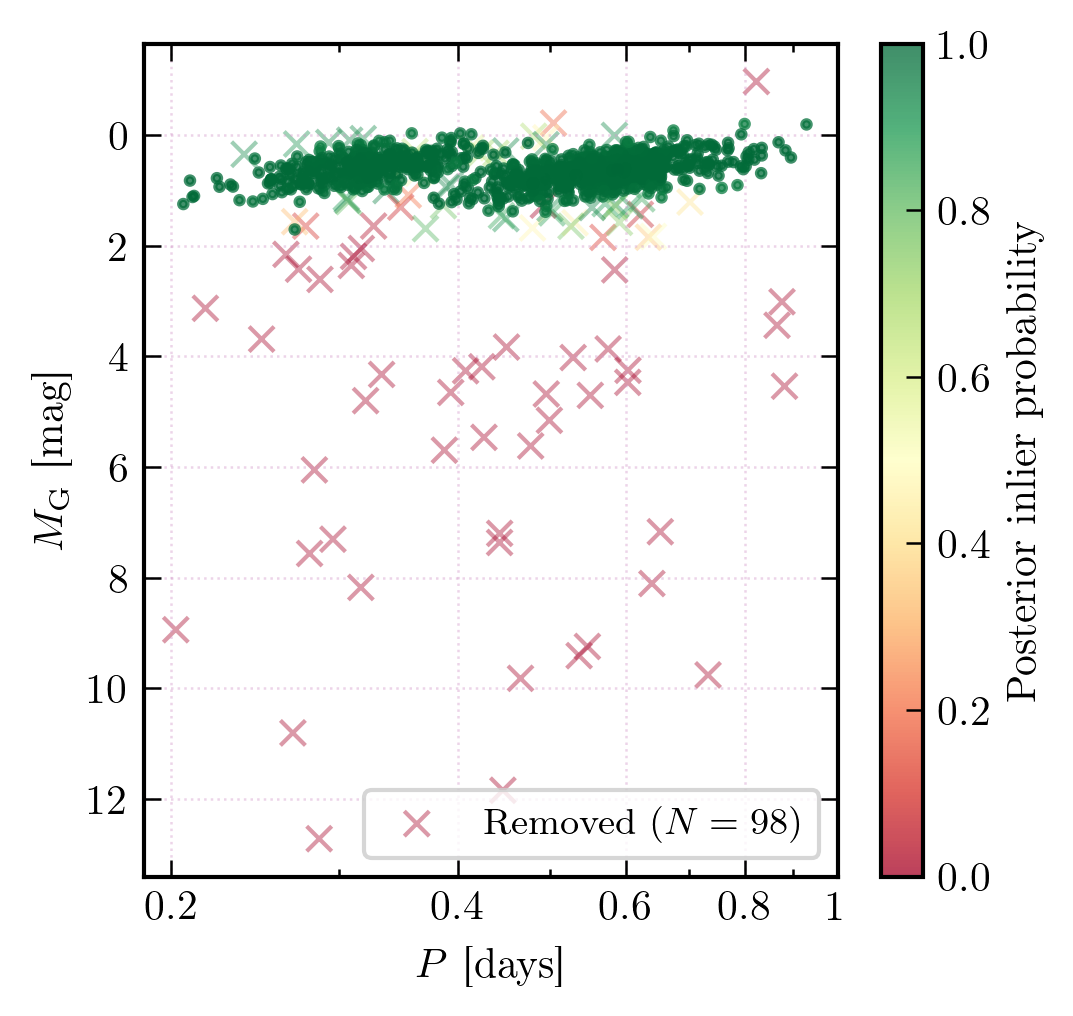

In [6]:
ax = plot_inlier_prob_period_luminosity_comparison(c12, clean)
plt.show()

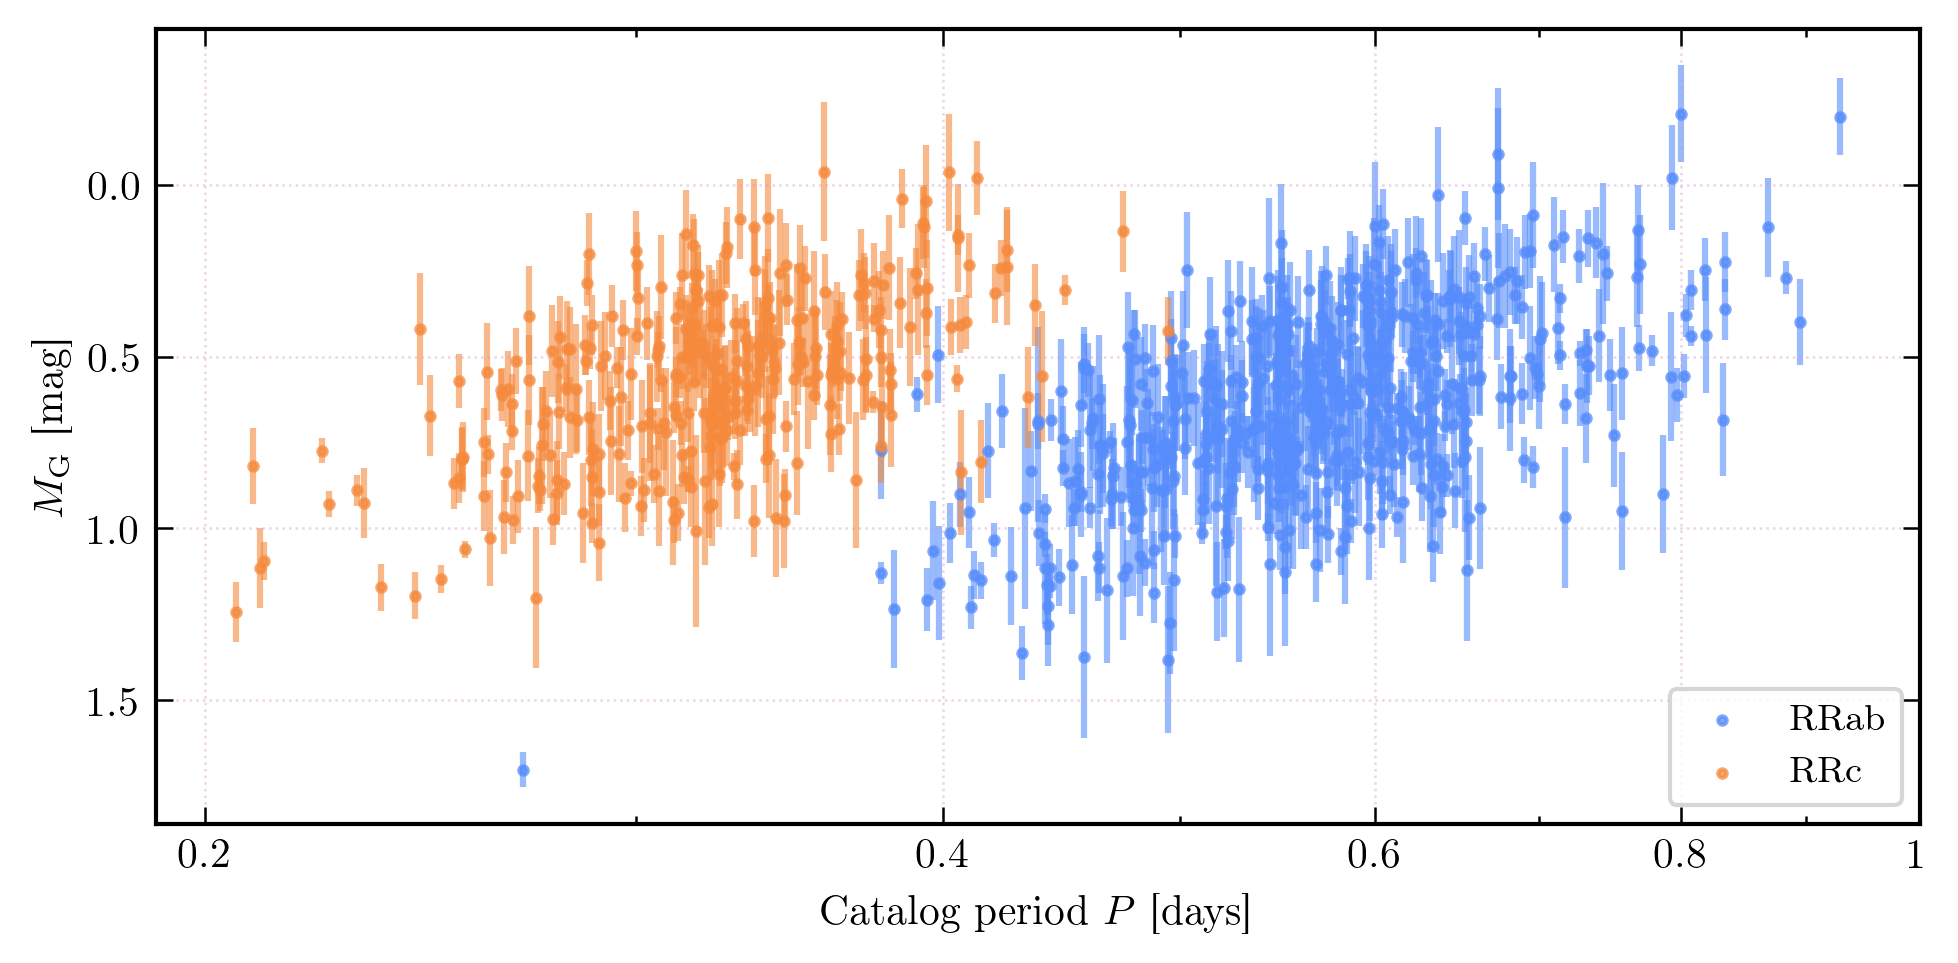

In [7]:
ax = plot_period_abs_mag(rrlyrae_clean_data)
plt.show()

In [8]:
output_path = Path("rrlyrae_calibration_sample.npz")
arrays = {col: np.array(rrlyrae_clean_data[col]) for col in rrlyrae_clean_data.colnames}
np.savez_compressed(output_path, **arrays)